# Classic Sparsity Experiment

Este notebook avalia o cenário clássico de esparsidade com  > p$ (=200, p=50$), onde apenas 10 variáveis são verdadeiramente informativas e 40 são ruído puro (coeficiente nulo), sem correlação entre preditores.

**Objetivo:** Avaliar a capacidade dos métodos (especialmente LASSO e Elastic Net) de realizar seleção de variáveis (*sparsity recovery*), zerando os coeficientes irrelevantes, em comparação com OLS e Ridge (que não promove esparsidade).


## 0. Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Import data generation
from data_generation.generate_data import generate_data

# Import plots
from plots.coefficient_plot import coefficient_plot
from plots.metrics import compute_metrics

# Import models
from models.OLS import run_ols
from models.LASSO import run_lasso, run_lasso_cv
from models.Ridge import run_ridge, run_ridge_cv
from models.ElasticNet import run_elasticnet_alpha, run_elasticnet_l1ratio, run_elasticnet_cv

# Removing Warnings
import warnings


In [2]:
warnings.filterwarnings('ignore')

## 1. Generating Data

GENERATED DATA:
Shape of X: (200, 50)

X Matrix: 
 [[-9.24357334e-01 -3.26535853e-01 -1.87500739e+00 ... -4.28318258e-01
   2.93949388e-01 -1.51383050e+00]
 [ 1.79487288e-03 -1.28559911e+00 -7.26774138e-01 ... -1.72041359e-01
  -1.67176127e+00  2.10008308e-01]
 [ 9.56702317e-01  2.31932954e+00 -7.05011856e-01 ...  1.09131012e+00
  -1.33123295e+00 -1.10336661e+00]
 ...
 [ 9.93138150e-02  2.30806590e-02 -2.36747765e+00 ... -4.35789730e-01
   5.16144040e-01 -5.27994022e-01]
 [-5.11186930e-02  3.04764139e-02 -1.11318849e-01 ...  2.40876757e-01
   1.43306305e-01 -1.75543790e+00]
 [-5.92464259e-01 -5.62168027e-01  2.88693629e-01 ... -1.10570467e+00
   2.80161159e-01 -4.73839347e-01]]
Shape of y: (200,)

y Vector: 
 [ 2.05556610e+01 -6.27115209e+01  1.36098236e+02 -1.33830039e+02
 -1.43076766e+02  1.59212611e+02  3.04345339e+01 -2.71157912e+02
  6.17720521e+01 -1.11022609e+02  1.04141333e+02  7.76494171e+00
  2.24681388e+02 -5.91914665e+01  3.13361861e+01  2.15976191e+02
  7.34888896e+01 -3.8

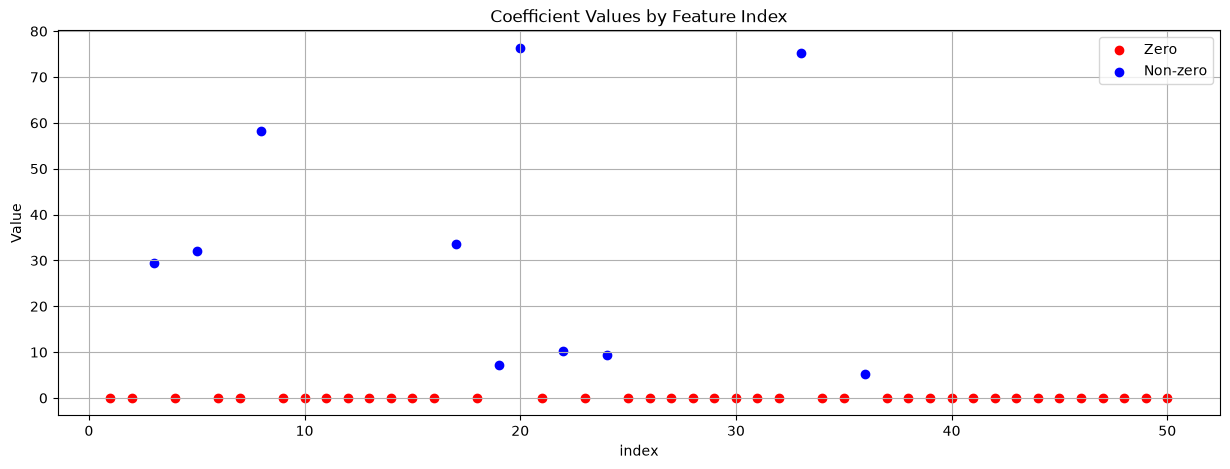

In [3]:
X_train, X_test, y_train, y_test, coef = generate_data(
    n_samples=200,
    n_features=50,
    n_informative=10,
    noise=1.0,
    effective_rank=None,
    tail_strength=0.5
)

coefficient_plot(coef)


## 2. Ordinary Least Square

MAE: 1.00
MSE: 1.59
RMSE: 1.26
R² Score: 1.00
Number of non zero coefs: 50
Max coef magnitude: 76.3919
Mean coef magnitude: 6.8065


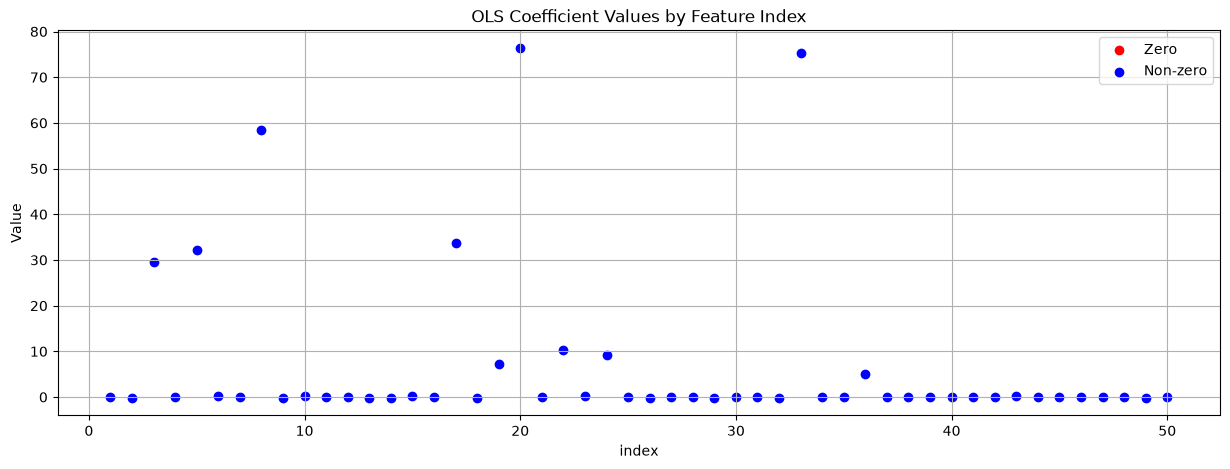

In [4]:
OLS_model = run_ols(X_train, X_test, y_train, y_test, compute_metrics, coefficient_plot)

## 3. Least Absolute Shrinkage and Selection Operator

Metrics for i = 0.001:
MAE: 0.99
MSE: 1.58
RMSE: 1.26
R² Score: 1.00
Number of non zero coefs: 49
Max coef magnitude: 76.3935
Mean coef magnitude: 6.8048


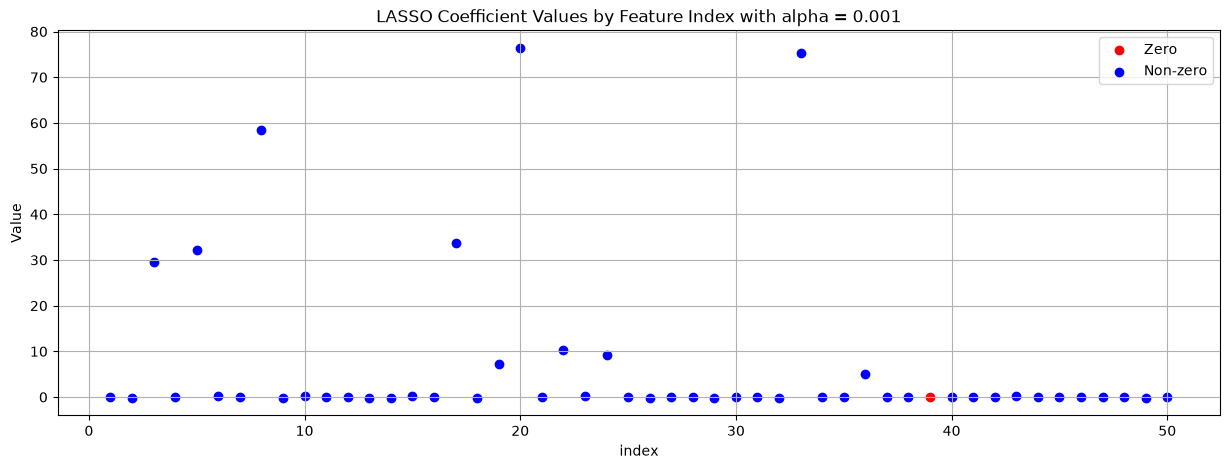

Metrics for i = 0.01:
MAE: 0.95
MSE: 1.46
RMSE: 1.21
R² Score: 1.00
Number of non zero coefs: 42
Max coef magnitude: 76.3868
Mean coef magnitude: 6.7929


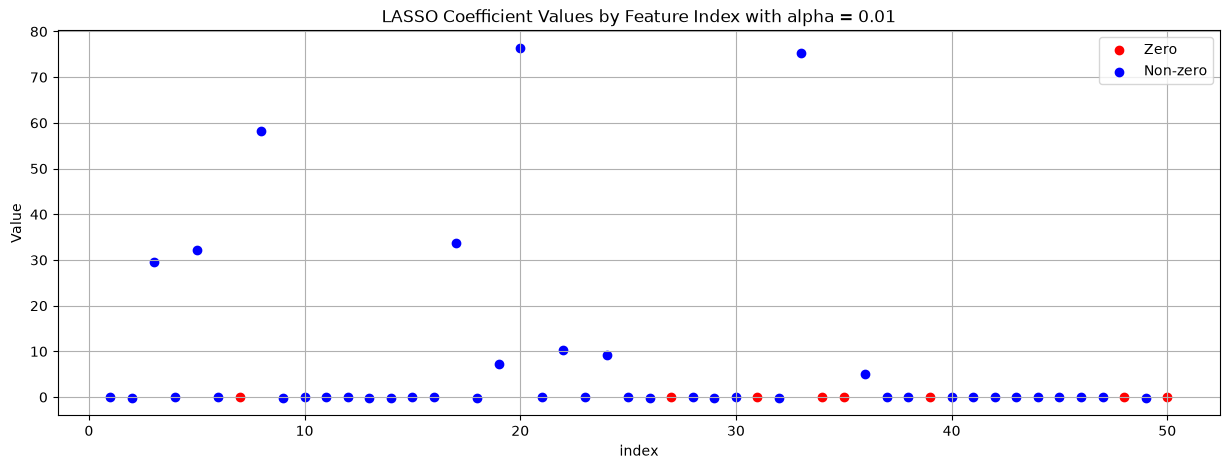

Metrics for i = 0.1:
MAE: 0.83
MSE: 1.11
RMSE: 1.05
R² Score: 1.00
Number of non zero coefs: 20
Max coef magnitude: 76.2996
Mean coef magnitude: 6.7292


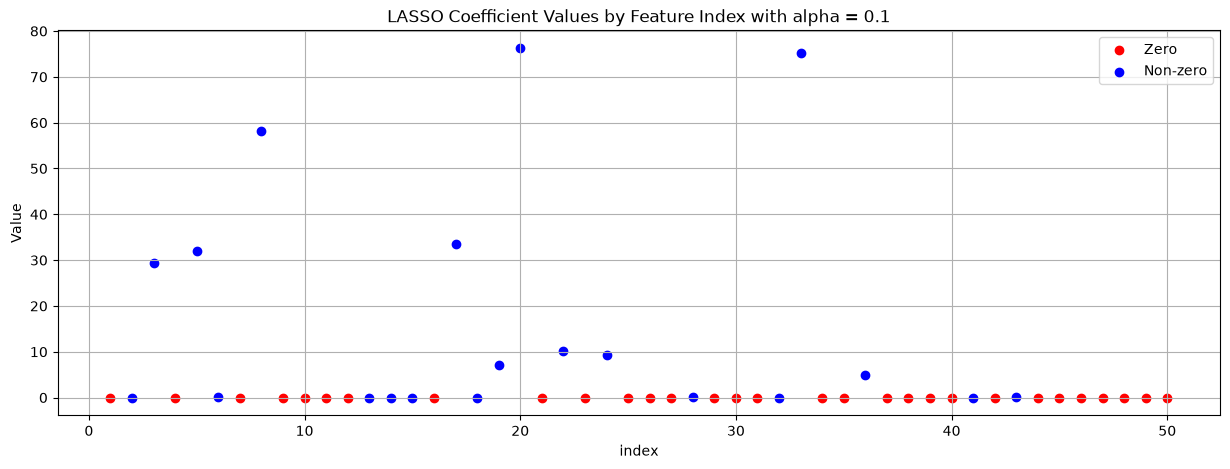

Metrics for i = 1.0:
MAE: 2.70
MSE: 11.73
RMSE: 3.43
R² Score: 1.00
Number of non zero coefs: 10
Max coef magnitude: 75.5451
Mean coef magnitude: 6.5316


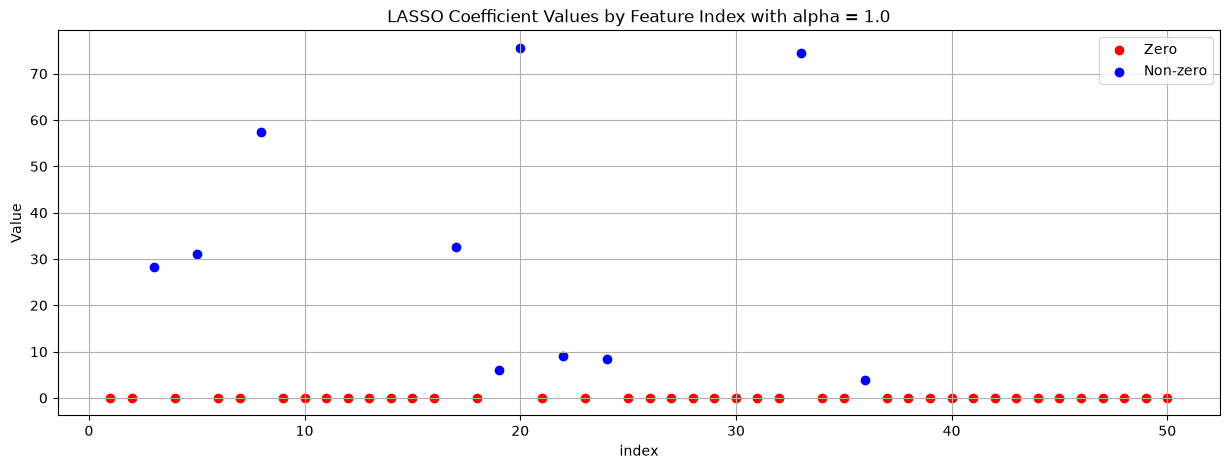

Metrics for i = 10.0:
MAE: 23.06
MSE: 766.36
RMSE: 27.68
R² Score: 0.94
Number of non zero coefs: 6
Max coef magnitude: 67.0927
Mean coef magnitude: 4.9040


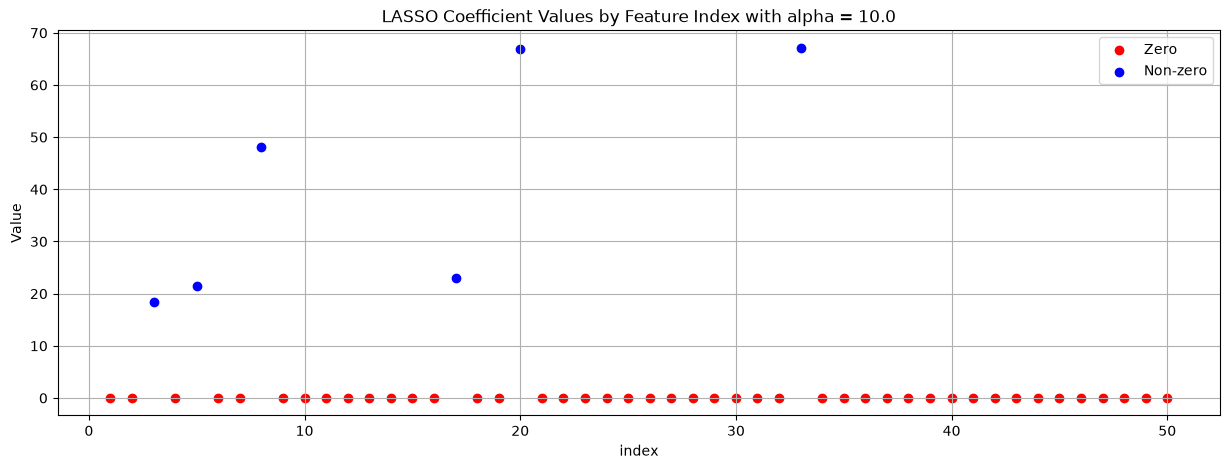

Metrics for i = 100.0:
MAE: 94.09
MSE: 12137.69
RMSE: 110.17
R² Score: -0.01
Number of non zero coefs: 0
Max coef magnitude: 0.0000
Mean coef magnitude: 0.0000


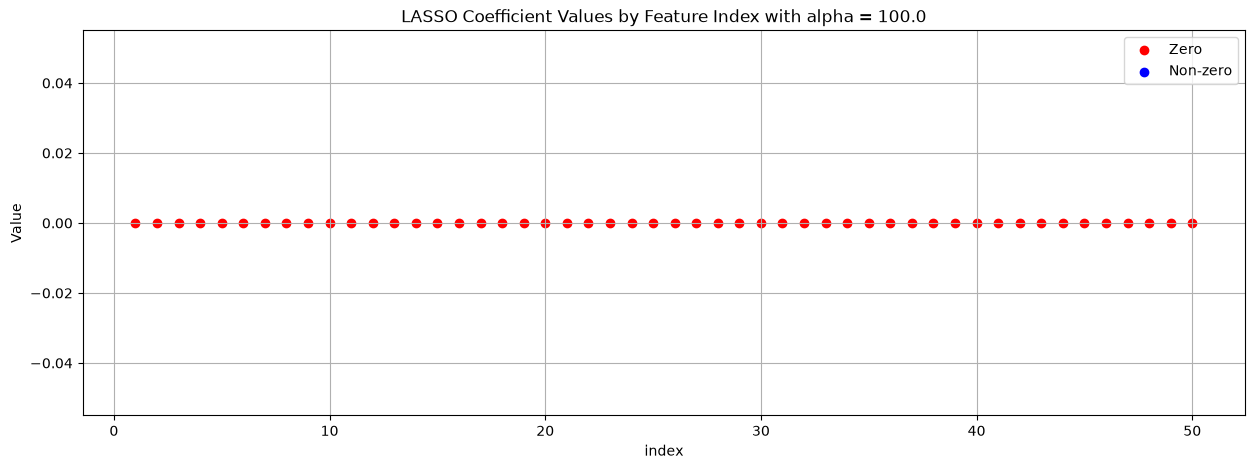

In [5]:
run_lasso(X_train, X_test, y_train, y_test, compute_metrics, coefficient_plot)

### Best alpha for LASSO

MAE: 0.95
MSE: 1.48
RMSE: 1.22
R² Score: 1.00
Number of non zero coefs: 10
Max coef magnitude: 76.1875
Mean coef magnitude: 6.6911


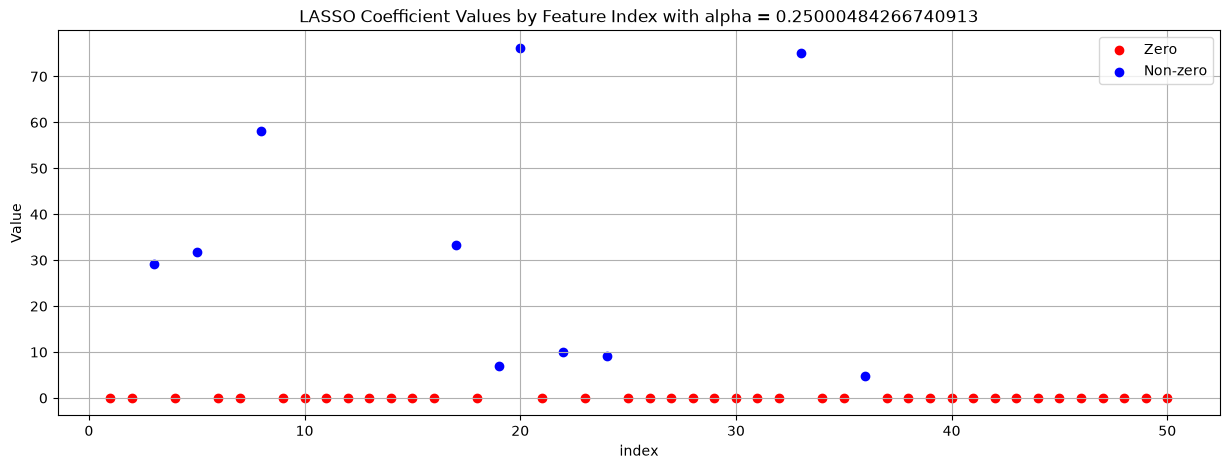

In [6]:
LASSOCV_model = run_lasso_cv(X_train, X_test, y_train, y_test, compute_metrics, coefficient_plot)

## 4. Ridge

Metrics for i = 0.001:
MAE: 1.00
MSE: 1.59
RMSE: 1.26
R² Score: 1.00
Number of non zero coefs: 50
Max coef magnitude: 76.3910
Mean coef magnitude: 6.8064


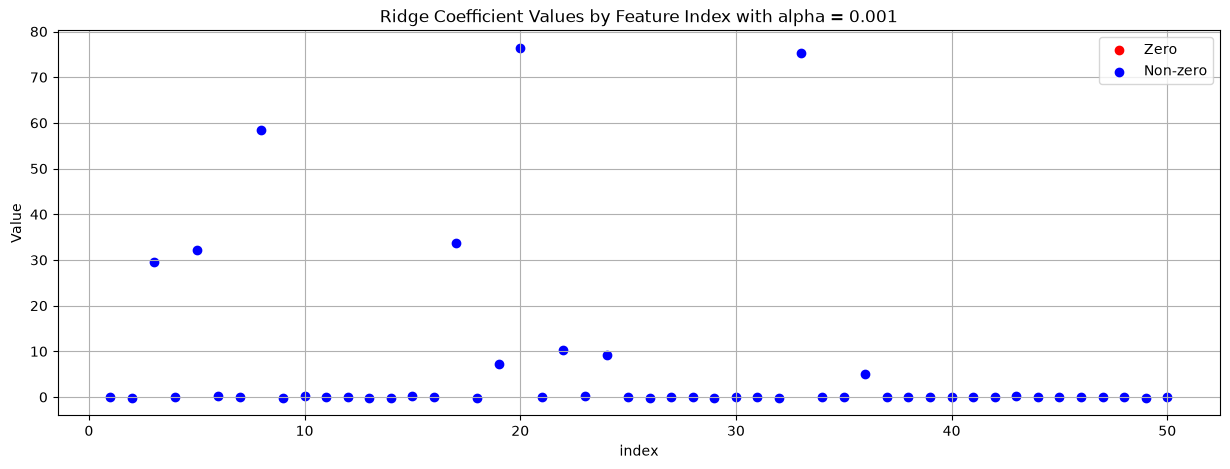

Metrics for i = 0.01:
MAE: 1.00
MSE: 1.59
RMSE: 1.26
R² Score: 1.00
Number of non zero coefs: 50
Max coef magnitude: 76.3834
Mean coef magnitude: 6.8060


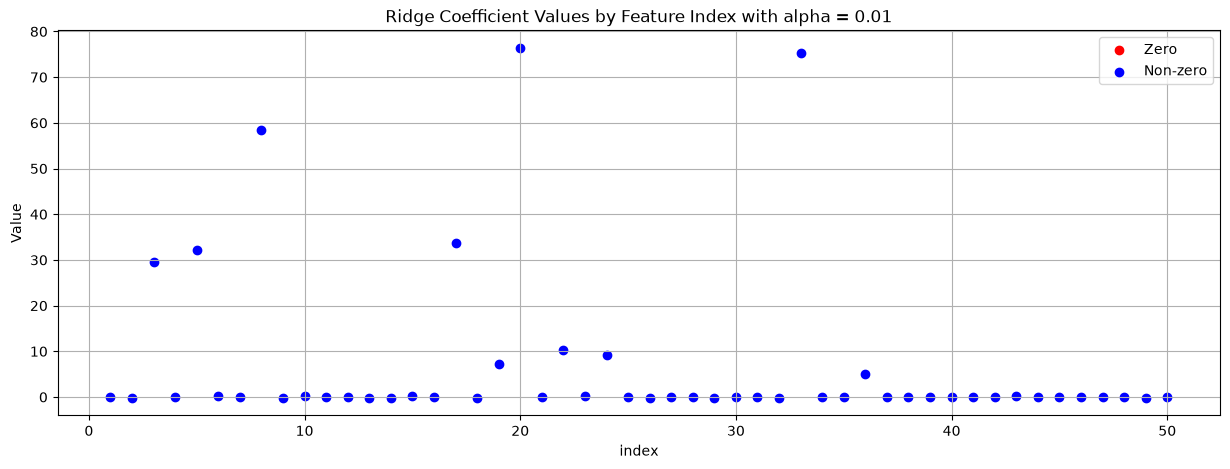

Metrics for i = 0.1:
MAE: 1.00
MSE: 1.58
RMSE: 1.26
R² Score: 1.00
Number of non zero coefs: 50
Max coef magnitude: 76.3074
Mean coef magnitude: 6.8028


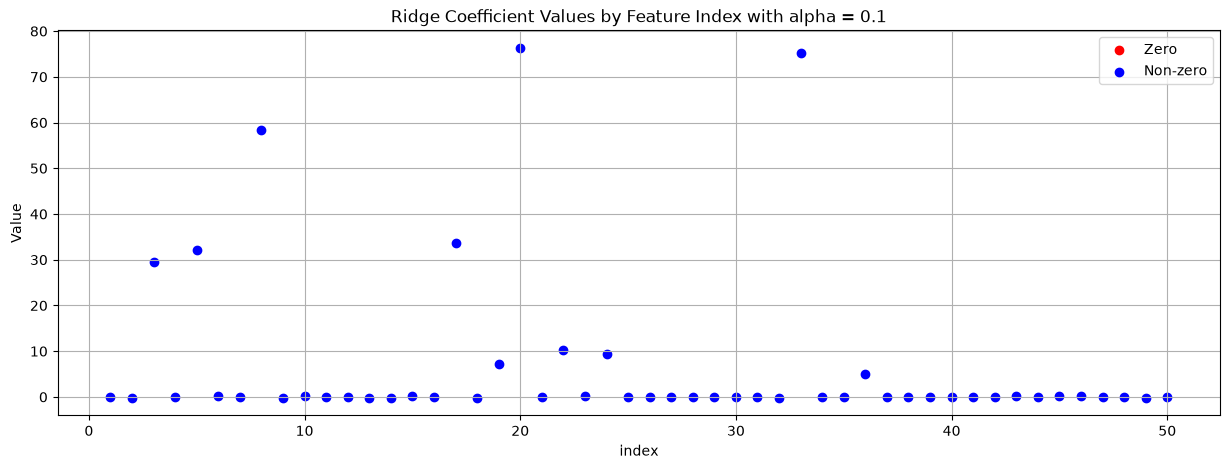

Metrics for i = 1.0:
MAE: 1.41
MSE: 2.94
RMSE: 1.72
R² Score: 1.00
Number of non zero coefs: 50
Max coef magnitude: 75.5592
Mean coef magnitude: 6.7943


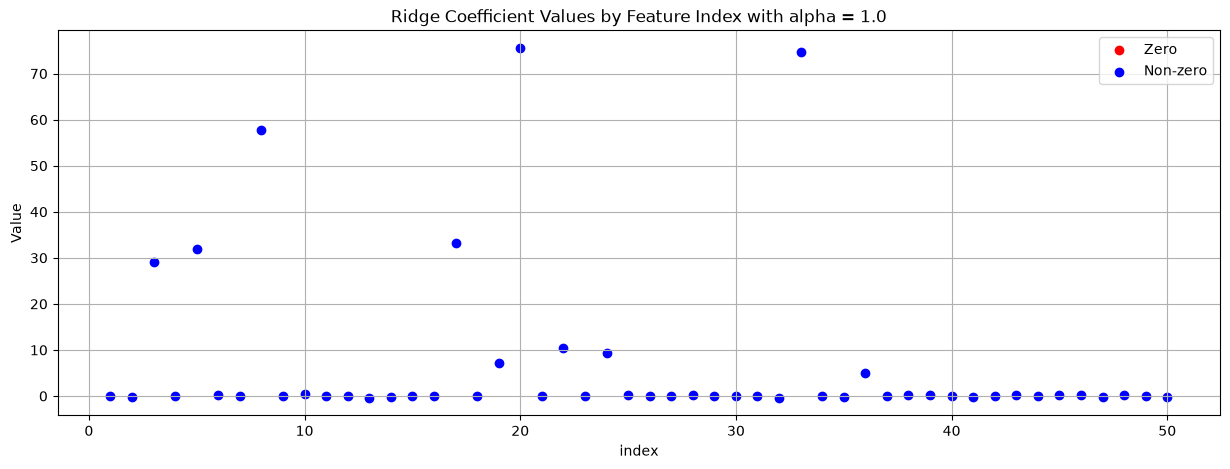

Metrics for i = 10.0:
MAE: 9.51
MSE: 124.46
RMSE: 11.16
R² Score: 0.99
Number of non zero coefs: 50
Max coef magnitude: 70.1646
Mean coef magnitude: 6.9392


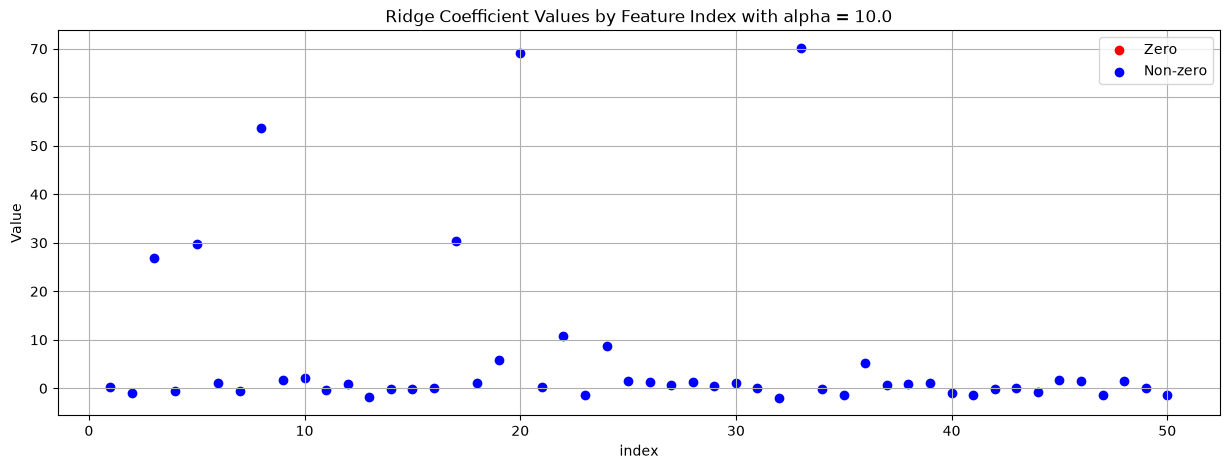

Metrics for i = 100.0:
MAE: 44.05
MSE: 2704.76
RMSE: 52.01
R² Score: 0.78
Number of non zero coefs: 50
Max coef magnitude: 46.5099
Mean coef magnitude: 6.0529


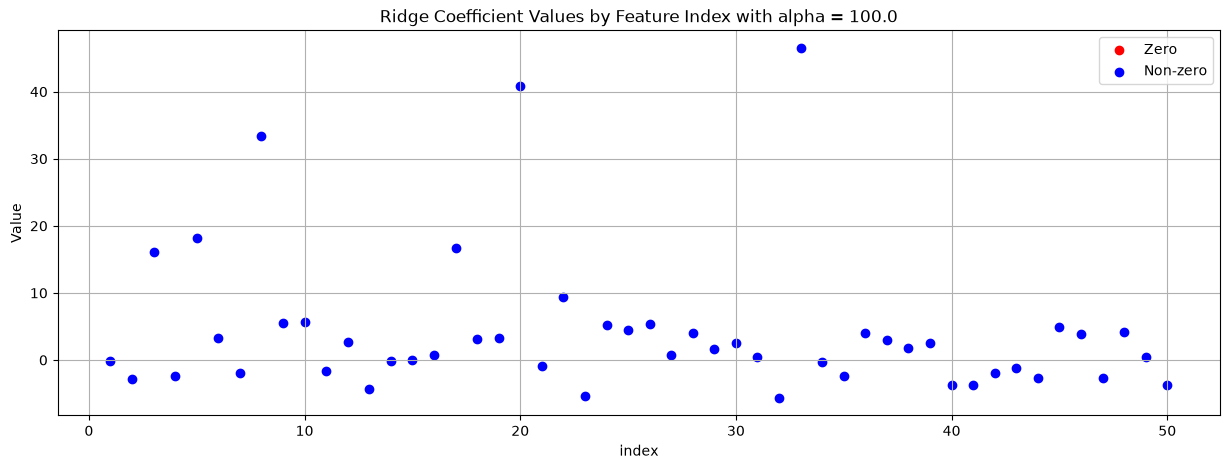

In [7]:
run_ridge(X_train, X_test, y_train, y_test, compute_metrics, coefficient_plot)

### Ridge Best Alpha

MAE: 1.00
MSE: 1.58
RMSE: 1.26
R² Score: 1.00
Number of non zero coefs: 50
Max coef magnitude: 76.3074
Mean coef magnitude: 6.8028


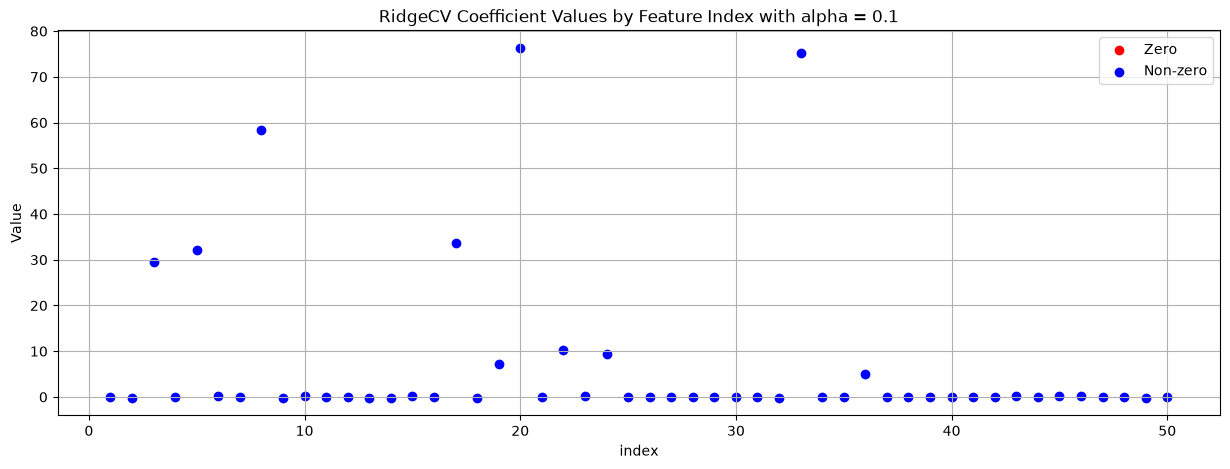

In [8]:
RidgeCV_model = run_ridge_cv(X_train, X_test, y_train, y_test, compute_metrics, coefficient_plot)

## 5. Elastic Net

Metrics for i = 0.001:
MAE: 1.00
MSE: 1.57
RMSE: 1.25
R² Score: 1.00
Number of non zero coefs: 50
Max coef magnitude: 76.3252
Mean coef magnitude: 6.8024


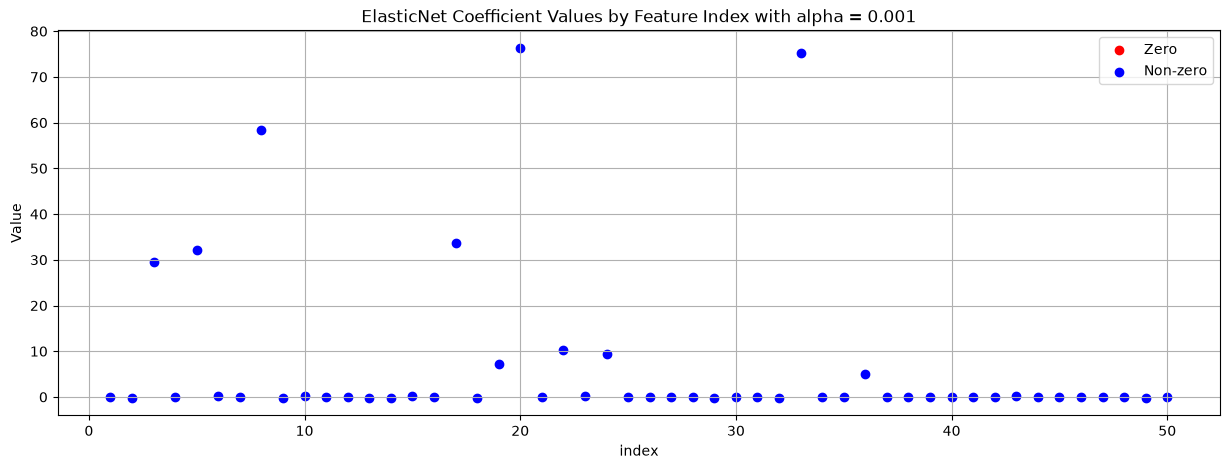

Metrics for i = 0.01:
MAE: 1.27
MSE: 2.34
RMSE: 1.53
R² Score: 1.00
Number of non zero coefs: 48
Max coef magnitude: 75.7308
Mean coef magnitude: 6.7852


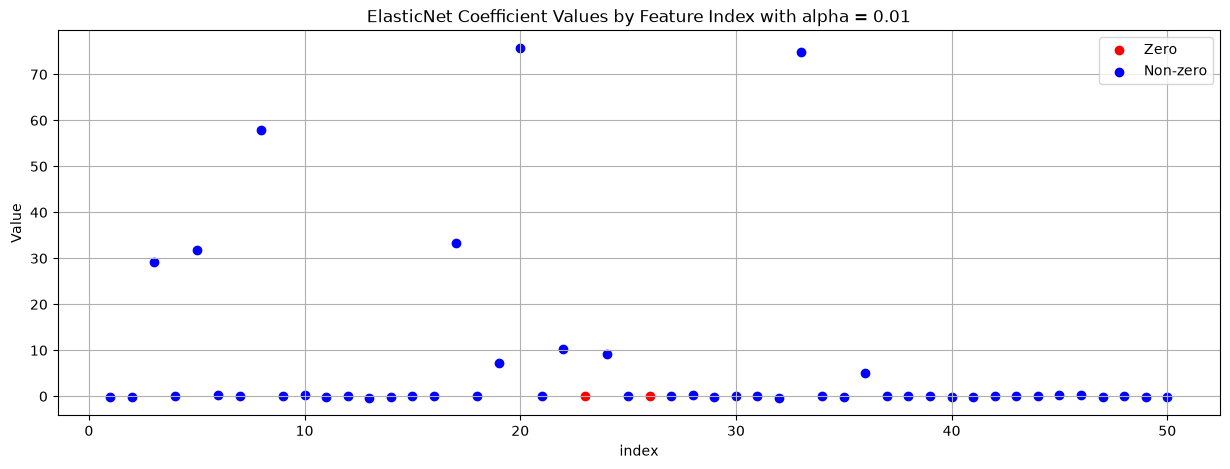

Metrics for i = 0.1:
MAE: 7.62
MSE: 79.47
RMSE: 8.91
R² Score: 0.99
Number of non zero coefs: 46
Max coef magnitude: 71.1385
Mean coef magnitude: 6.8486


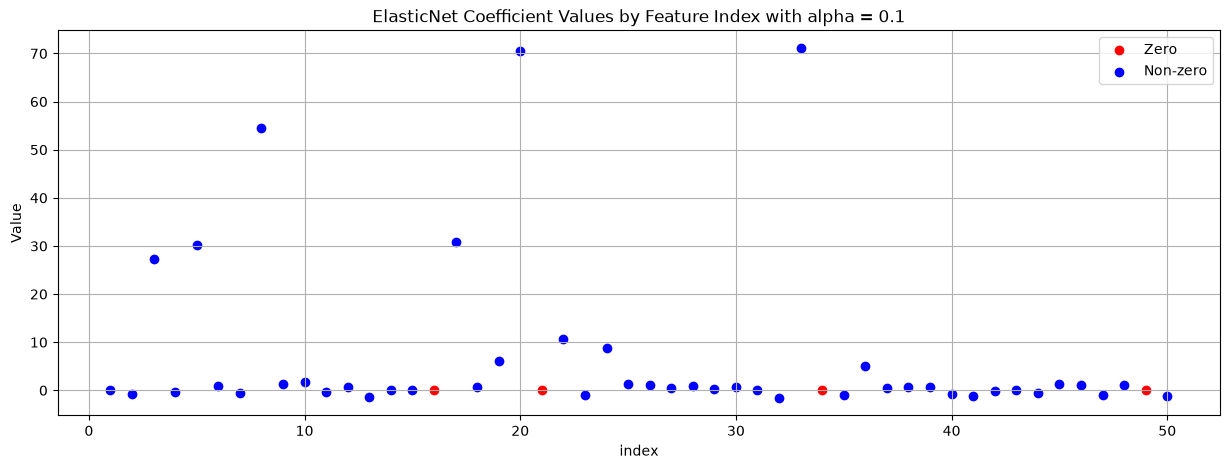

Metrics for i = 1.0:
MAE: 39.33
MSE: 2145.63
RMSE: 46.32
R² Score: 0.82
Number of non zero coefs: 46
Max coef magnitude: 49.9786
Mean coef magnitude: 6.0108


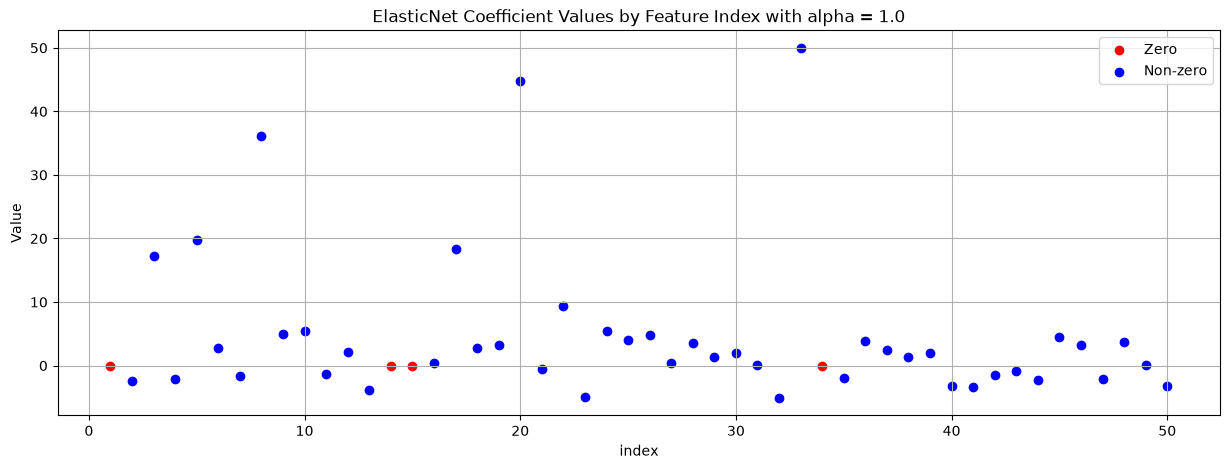

Metrics for i = 10.0:
MAE: 80.80
MSE: 8855.84
RMSE: 94.11
R² Score: 0.26
Number of non zero coefs: 37
Max coef magnitude: 13.7991
Mean coef magnitude: 1.5925


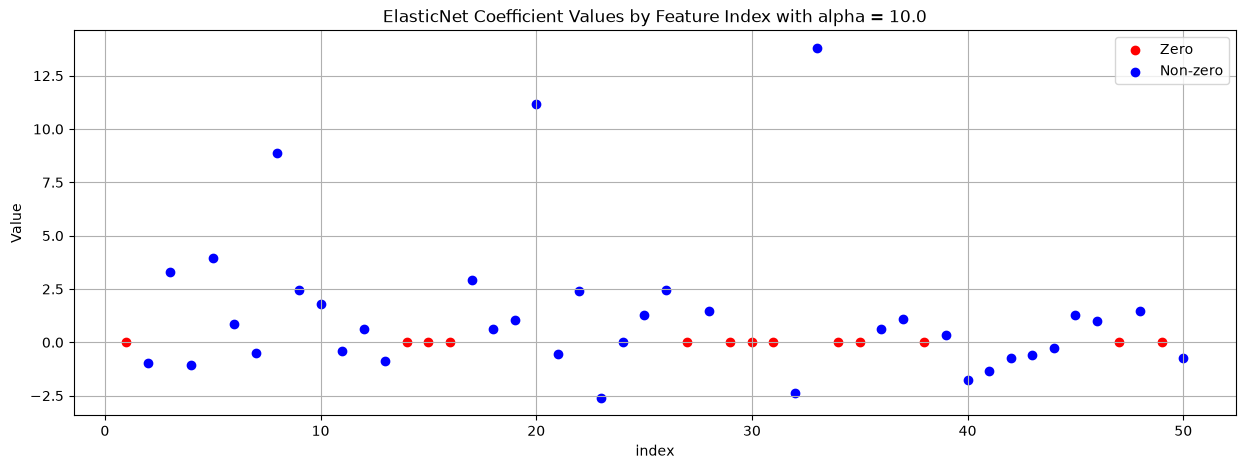

Metrics for i = 100.0:
MAE: 93.54
MSE: 11998.40
RMSE: 109.54
R² Score: 0.00
Number of non zero coefs: 3
Max coef magnitude: 0.8601
Mean coef magnitude: 0.0314


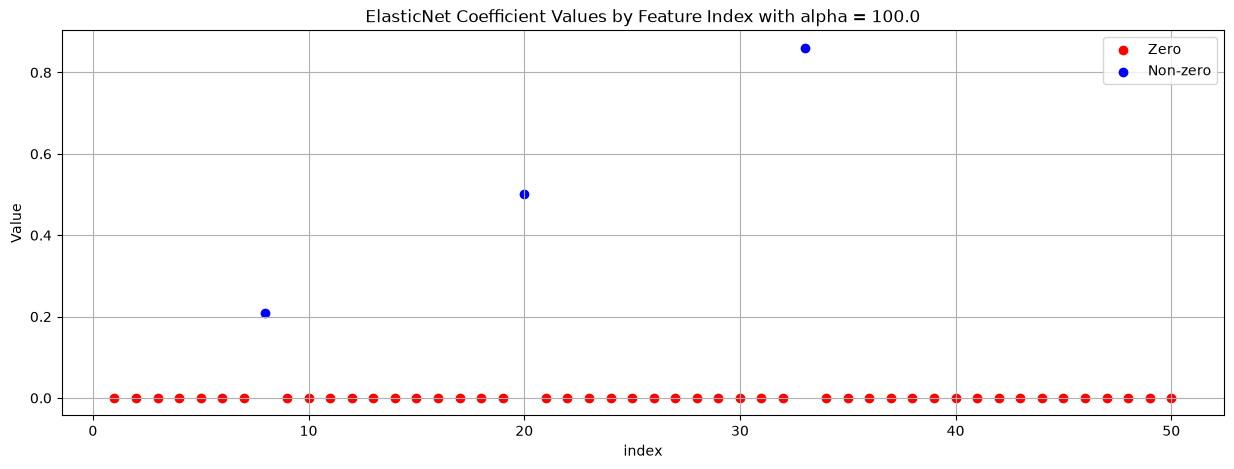

In [9]:
run_elasticnet_alpha(X_train, X_test, y_train, y_test, compute_metrics, coefficient_plot)

Metrics for i = 0.0:
MAE: 53.73
MSE: 3976.70
RMSE: 63.06
R² Score: 0.67
Number of non zero coefs: 50
Max coef magnitude: 38.6431
Mean coef magnitude: 5.3338


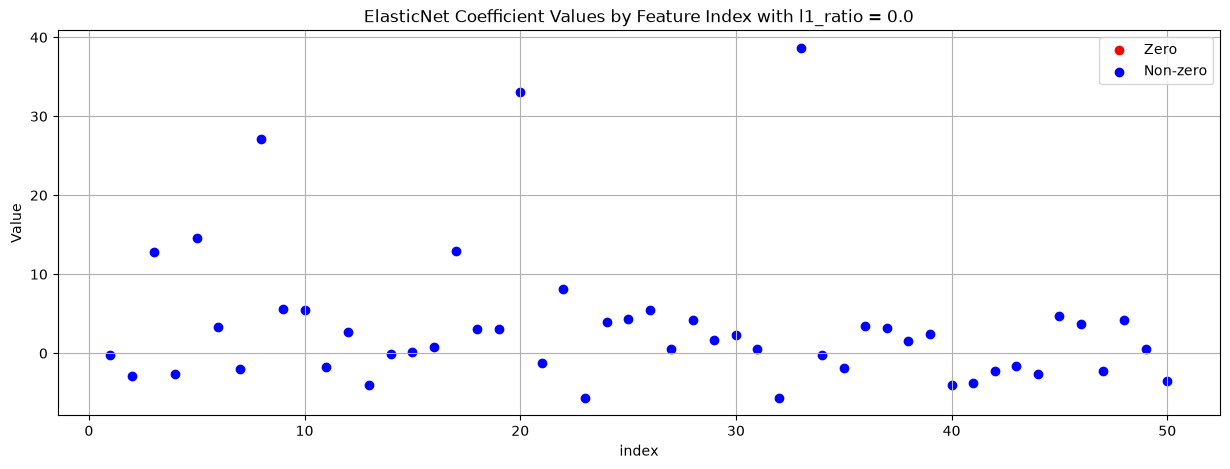

Metrics for i = 0.25:
MAE: 47.73
MSE: 3157.68
RMSE: 56.19
R² Score: 0.74
Number of non zero coefs: 48
Max coef magnitude: 43.4814
Mean coef magnitude: 5.6666


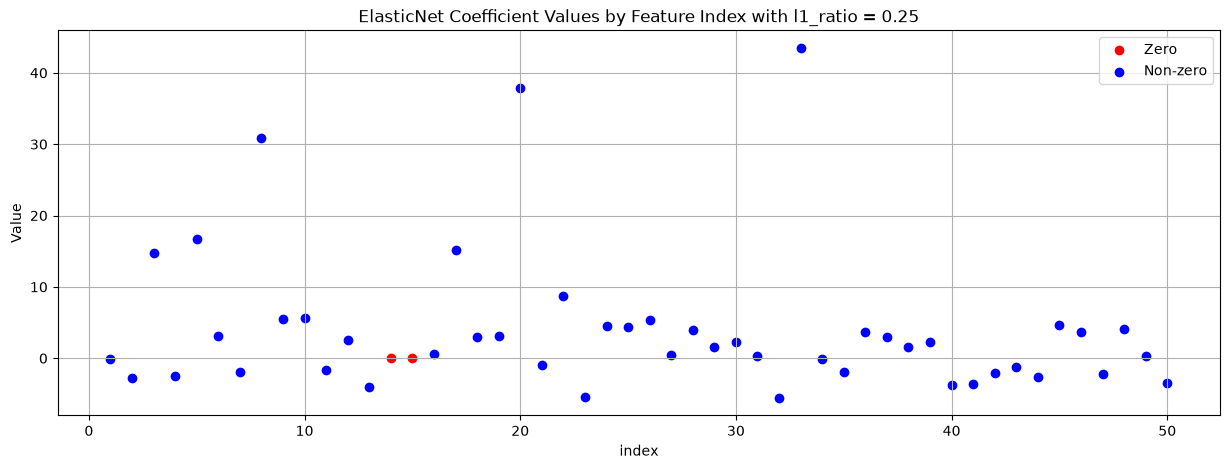

Metrics for i = 0.5:
MAE: 39.33
MSE: 2145.63
RMSE: 46.32
R² Score: 0.82
Number of non zero coefs: 46
Max coef magnitude: 49.9786
Mean coef magnitude: 6.0108


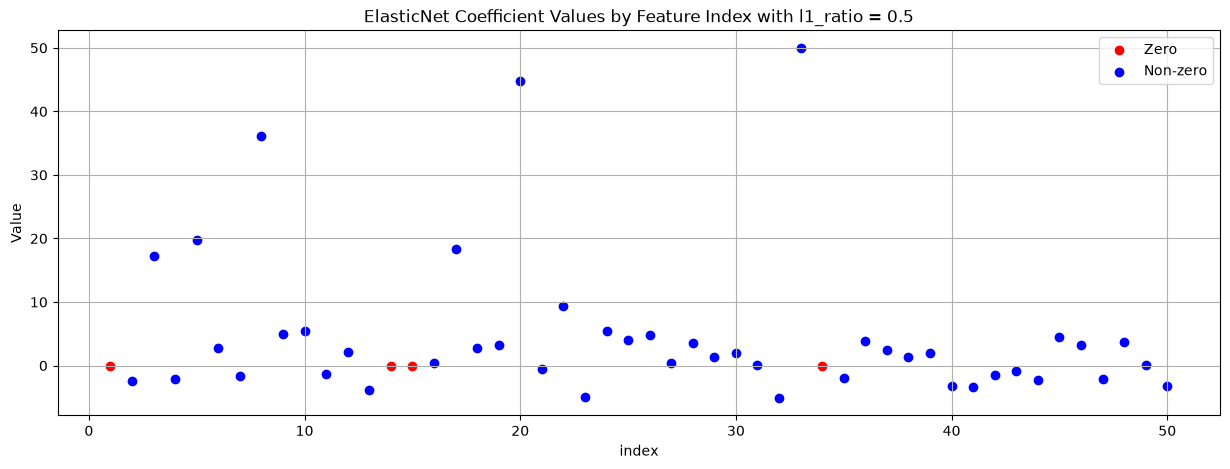

Metrics for i = 0.75:
MAE: 25.78
MSE: 917.22
RMSE: 30.29
R² Score: 0.92
Number of non zero coefs: 43
Max coef magnitude: 59.4878
Mean coef magnitude: 6.2611


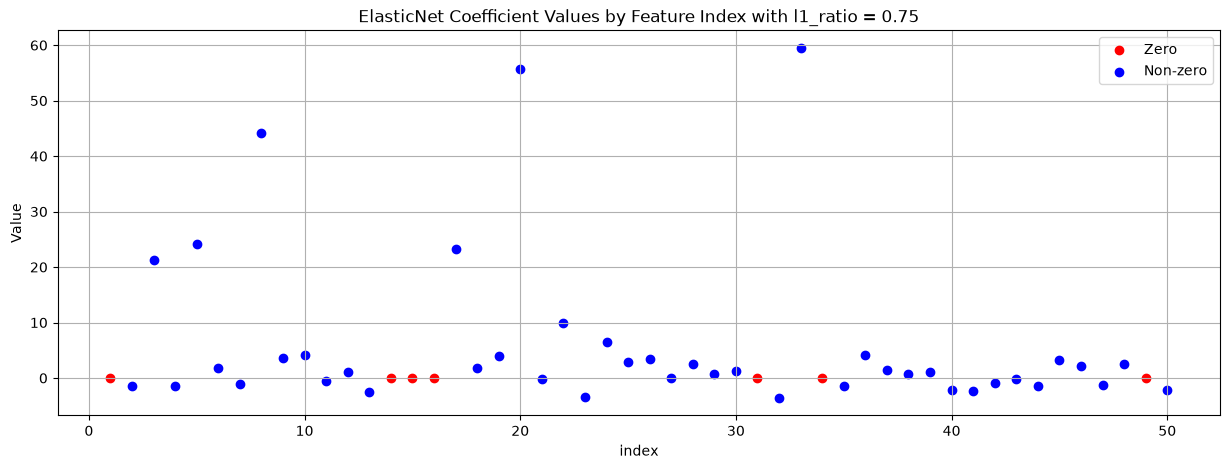

Metrics for i = 1.0:
MAE: 2.70
MSE: 11.73
RMSE: 3.43
R² Score: 1.00
Number of non zero coefs: 10
Max coef magnitude: 75.5451
Mean coef magnitude: 6.5316


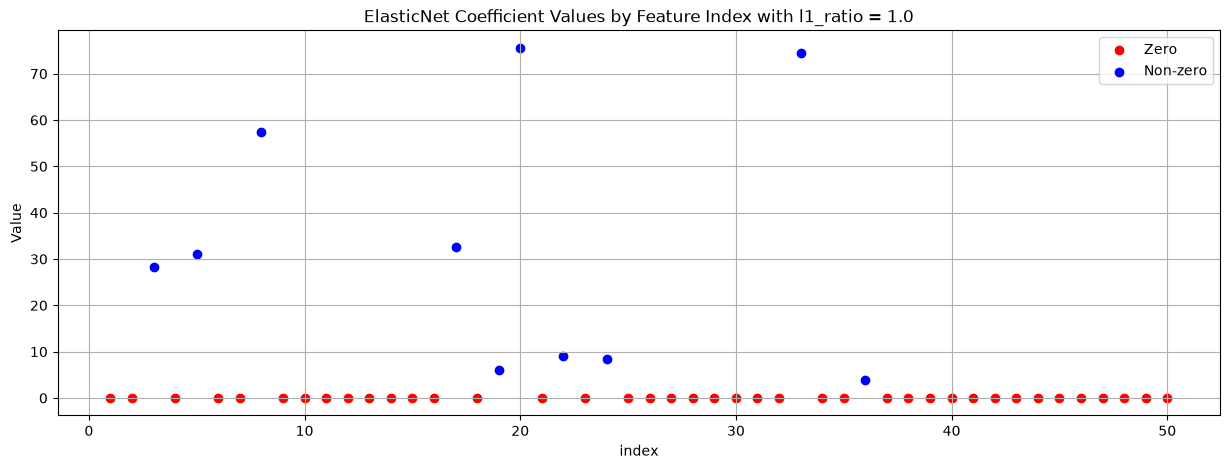

In [10]:
run_elasticnet_l1ratio(X_train, X_test, y_train, y_test, compute_metrics, coefficient_plot)

### Best alpha and l1 ratio for ElasticNet

In [ ]:
run_elasticnet_cv